# Figure 5A ROI review

This notebook shows the shared H&E region and reproduces the Cellpose3 and Cellpose-SAM source plots from the supplied ROI data.

The region is **200 x 200 pixels**, covering rows **3650-3849** and columns **5100-5299** in the processed H&E image. Coordinates start at zero in the upper-left corner.

Run the cells from top to bottom. The input data remain unchanged. The two generated plots are saved in `Reproduced`.

Required packages: `tifffile`, `pandas`, `matplotlib` and `seaborn`.


In [1]:
%matplotlib inline
from pathlib import Path
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

plt.rcdefaults()
ROOT = Path.cwd()
DATA = ROOT / "Source_data"
OUT = ROOT / "Reproduced"
assert DATA.is_dir(), "Run this notebook from the package main folder."
OUT.mkdir(exist_ok=True)
methods = ["Cellpose3", "Cellpose-SAM"]
he = tifffile.imread(DATA / "HE_ROI.tif")
palette = pd.read_csv(DATA / "celltype_colors.csv")
boundaries = {}
cells = {}
for method in methods:
    mask = tifffile.imread(DATA / f"{method}_mask.tif")
    boundaries[method] = tifffile.imread(DATA / f"{method}_boundary.tif").astype(bool)
    assert he.shape == (200, 200, 3)
    assert mask.shape == boundaries[method].shape == (200, 200)
    cells[method] = pd.read_csv(DATA / f"{method}_cells.csv")
    cells[method]["C_scANVI"] = pd.Categorical(
        cells[method]["C_scANVI"], categories=palette["cell_type"].tolist(), ordered=True
    )
print("Loaded the shared H&E ROI and both methods' saved results.")


Loaded the shared H&E ROI and both methods' saved results.


## Shared H&E region

The same H&E crop is used for both methods. The image below has no boundaries or annotation points.


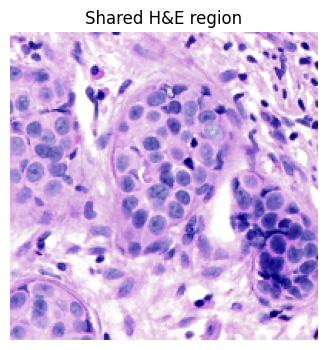

In [2]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(he)
ax.set_axis_off()
ax.set_title("Shared H&E region")
plt.show()


## Recreate the source plots

The drawing settings match the archived source panels: `Reds` boundary colors, opacity `0.6`, the saved cell-type palette and marker size `10`.

The boundaries were extracted from the complete segmentation label maps before cropping. In the annotation tables, `center_x` is the local row and `center_y` is the local column.


In [3]:
def draw_method(method, ax):
    table = cells[method]
    ax.imshow(he, aspect="auto")
    ax.imshow(boundaries[method], cmap="Reds", alpha=0.6)
    sns.scatterplot(
        x=table["center_y"], y=table["center_x"], hue=table["C_scANVI"],
        s=10, palette=palette["color_hex"].tolist(), edgecolors="none", ax=ax
    )
    ax.set_axis_off()

def reproduce_method(method):
    fig, ax = plt.subplots(figsize=(6, 6))
    draw_method(method, ax)
    ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    fig.savefig(OUT / f"{method}.png", dpi=300, bbox_inches="tight")
    plt.show()


## Cellpose3

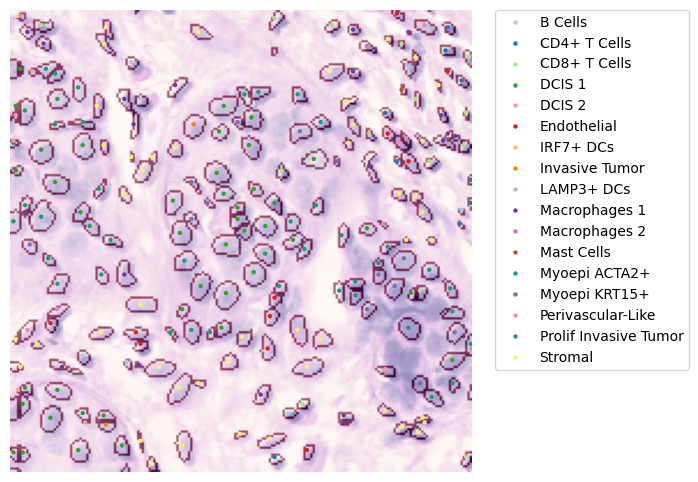

In [4]:
reproduce_method("Cellpose3")

## Cellpose-SAM

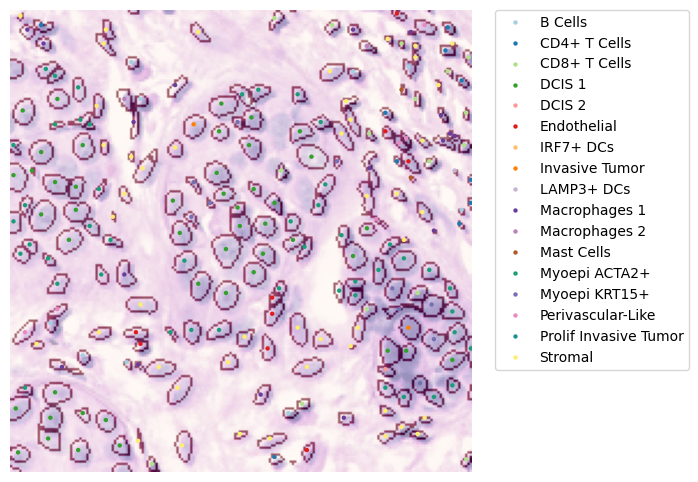

In [5]:
reproduce_method("Cellpose-SAM")

## Side-by-side view

The two methods are shown at the same scale on the shared H&E background. This view makes their different boundaries and annotation points easier to inspect.


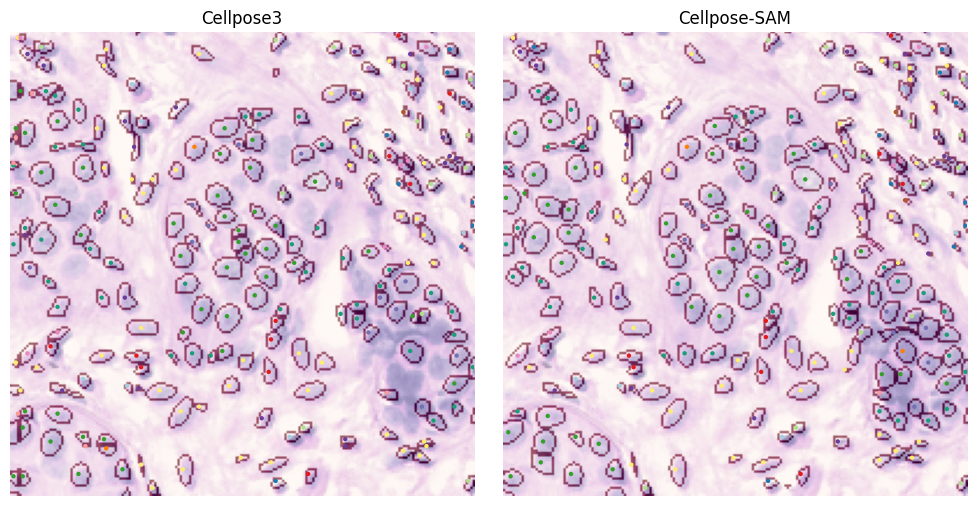

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for method, ax in zip(methods, axes):
    draw_method(method, ax)
    ax.get_legend().remove()
    ax.set_title(method)
plt.tight_layout()
plt.show()


## Preserved original results

The archived source-panel PDFs are preserved separately:

- [Cellpose3 source panel](Original_results/Cellpose3_source.pdf)
- [Cellpose-SAM source panel](Original_results/Cellpose-SAM_source.pdf)

The images below are the preserved crops from the final assembled figure. The plotting cells above recreate the RGB source panels; the final crops retain the assembled figure's display colors.


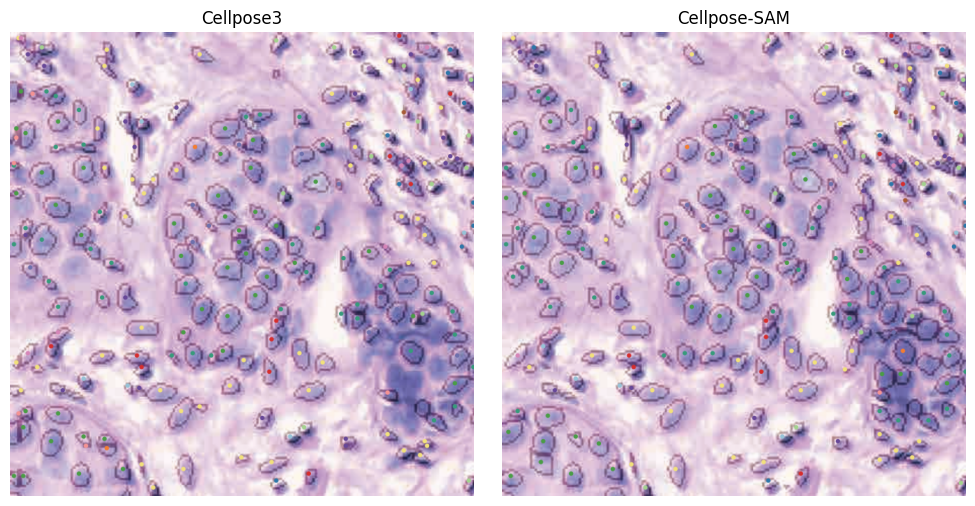

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for method, ax in zip(methods, axes):
    with Image.open(ROOT / "Original_results" / f"{method}_final.png") as original:
        ax.imshow(original.copy())
    ax.set_title(method)
    ax.set_axis_off()
plt.tight_layout()
plt.show()


## Inspect the annotation coordinates

This table shows a few of the saved Cellpose3 annotations. Rows and columns are local to the displayed crop; cell IDs and cell-type labels come from the saved annotation results.


In [8]:
display(
    cells["Cellpose3"].rename(columns={
        "center_x": "row", "center_y": "column", "C_scANVI": "cell_type"
    })[["cell_id", "row", "column", "cell_type"]].head()
)


,cell_id,row,column,cell_type
0,115740,2.0,3.0,Stromal
1,115789,41.0,2.0,DCIS 1
2,115796,45.0,2.0,DCIS 2
3,115816,57.0,1.0,Myoepi ACTA2+
4,115838,87.0,6.0,Macrophages 1
